# Consolidated Homing/Escape Detection Pipeline

Clean, streamlined workflow for Phase 1-3 homing detection analysis.  
Pipeline for learning features of manually labelled homings and applying them to a new homing detection logic

In [64]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path

from behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated import HomingAnalyzer
from settings.settings_analyze_behave import Settings

%matplotlib inline

In [65]:
# Import experiments
from behave_analysis.database.Experiments.JAL004_ex import (
    JAL4_flip4_3Sept, JAL4_flip6_19Sept, JAL4_flip3_28aug, JAL4_flip5_11Sept
)
from behave_analysis.database.Experiments.JAL005_ex import JAL5_flip1_8Sept, JAL5_flip3_21Sept
from behave_analysis.database.Experiments.JAL006_ex import (
    JAL6_flip6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, JAL6_flip5_25mar
)
from behave_analysis.database.Experiments.JAL007_ex import (
    JAL7_flip8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_flip9_16apr, JAL7_flip10_23apr
)
from behave_analysis.database.Experiments.JAL008_ex import (
    JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_flip5_14may, JAL8_flip4_10may
)

experiments_objects = [JAL4_flip4_3Sept,
    JAL4_flip6_19Sept,
    JAL4_flip3_28aug,
    JAL4_flip5_11Sept,
    JAL5_flip1_8Sept,
    JAL5_flip3_21Sept,
    JAL6_flip6_28mar,
    JAL6_flip4_21mar,
    JAL6_flip3_18mar,
    JAL6_flip5_25mar,
    JAL7_flip8_9apr,
    JAL7_flip5_22mar,
    JAL7_flip2_12mar,
    JAL7_flip9_16apr,
    JAL7_flip10_23apr,
    JAL8_flip1_25apr,
    JAL8_flip2_29apr,
    JAL8_flip3_7may,
    JAL8_flip5_14may,
    JAL8_flip4_10may,
]

In [67]:
# Initialize and load data

analyzer = HomingAnalyzer(experiments_objects, Settings)
analyzer.load_all_sessions()
print(f"✓ Loaded {len(analyzer.session_data)} sessions")

2026-07-08 15:33:47.622 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:load_all_sessions:105 - Loading 20 sessions...
2026-07-08 15:34:16.822 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.homing_load_manual_labels:load_manual_labels:20 - Loaded manual labels
2026-07-08 15:34:16.824 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.homing_load_manual_labels:load_manual_labels:21 - Number of homings: 67
2026-07-08 15:34:16.845 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:load_all_sessions:143 -   ✓ JAL004_flip_2023_09_03
2026-07-08 15:34:48.149 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.homing_load_manual_labels:load_manual_labels:20 - Loaded manual labels
2026-07-08 15:34:48.149 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.homing_load_manual_labels:load_manual_labels:21 - Number of homings: 76
2026-07-08 15:34:48.190 | INFO     | b

✓ Loaded 20 sessions


In [128]:
# Phase 1: Extract runs and manual events
speed_threshold = 5#Settings.homings_speed_threshold
speed_gap_tolerance = Settings.homings_gap_tolerance
analyzer.extract_runs(speed_threshold=speed_threshold, gap_tolerance_frames=speed_gap_tolerance)
analyzer.extract_manual_runs()
analyzer.label_extracted_runs(overlap_threshold=0.5)

print(f"✓ Extracted {len(analyzer.extracted_runs)} runs")
print(f"✓ Extracted {len(analyzer.manual_runs)} manually-labelled events")

n_exploration = sum(1 for r in analyzer.extracted_runs if r.is_exploration)
print(f"  - {n_exploration} exploration runs")
print(f"  - {len(analyzer.extracted_runs) - n_exploration} target-overlapping runs")

2026-07-09 11:09:53.948 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:extract_runs:190 - Extracting runs (threshold=5 cm/s, gap_tolerance=1 frames)...
2026-07-09 11:09:54.748 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:extract_runs:229 -   ✓ Extracted 82279 runs across 20 sessions
2026-07-09 11:09:54.752 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:extract_manual_runs:233 - Extracting manually-labelled homing/escape runs...
2026-07-09 11:09:55.046 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:extract_manual_runs:264 -   ✓ Extracted 1923 manually-labelled runs
2026-07-09 11:09:55.048 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:label_extracted_runs:292 - Labeling extracted runs (overlap_threshold=0.5)...
2026-07-09 11:10:24.283 | INFO     | behave_analysis.analy

✓ Extracted 82279 runs
✓ Extracted 1923 manually-labelled events
  - 79560 exploration runs
  - 2719 target-overlapping runs


In [129]:
# Extract features for all runs
analyzer.extract_features()
print(f"✓ Extracted features for {len(analyzer.all_runs)} runs")

2026-07-09 11:10:39.838 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:extract_features:316 - Extracting features for all runs...
2026-07-09 11:11:21.775 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:extract_features:330 -   ✓ Extracted features for 84202 runs


✓ Extracted features for 84202 runs


2026-07-09 11:11:40.601 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:compute_feature_distributions:419 - Computing feature distributions (exploration vs manually-labelled)...
2026-07-09 11:11:48.725 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:compute_feature_distributions:496 -   Feature ranking (by |Cohen's d|):
2026-07-09 11:11:48.726 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:compute_feature_distributions:498 -     1. net_dy: d=3.103, AUC=0.990, p=0.000e+00
2026-07-09 11:11:48.729 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:compute_feature_distributions:498 -     2. net_distance: d=3.068, AUC=0.968, p=0.000e+00
2026-07-09 11:11:48.730 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:compute_feature_distributions:498 -     3. speed_peak: d=2.274, AUC=0.963, 

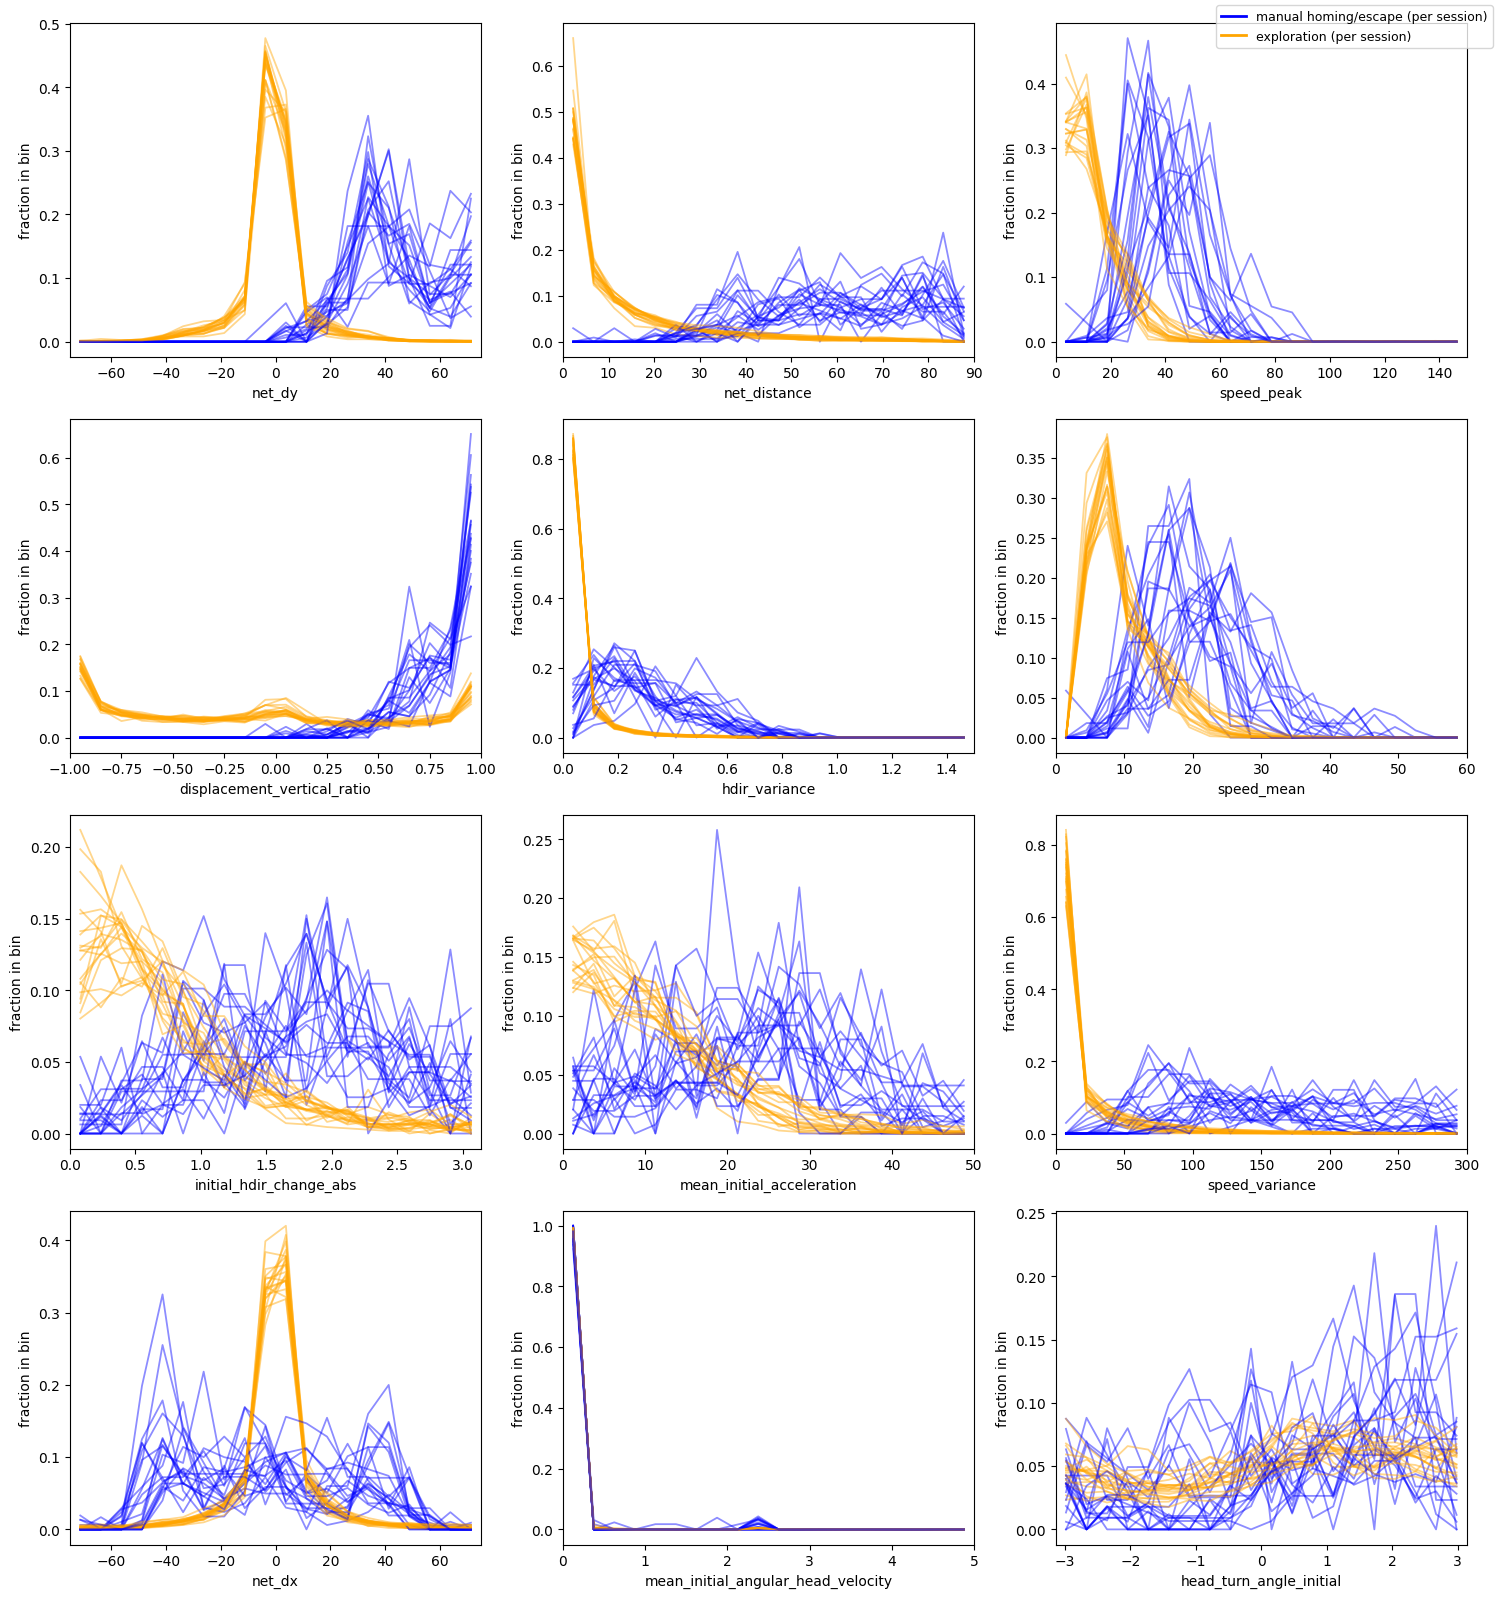


✓ Top discriminative features:
  1. net_dy: d=3.103, AUC_pooled=0.990, AUC_session_mean=0.989 (n_sessions=20)
  2. net_distance: d=3.068, AUC_pooled=0.968, AUC_session_mean=0.968 (n_sessions=20)
  3. speed_peak: d=2.274, AUC_pooled=0.963, AUC_session_mean=0.967 (n_sessions=20)
  4. displacement_vertical_ratio: d=1.907, AUC_pooled=0.882, AUC_session_mean=0.883 (n_sessions=20)
  5. hdir_variance: d=1.757, AUC_pooled=0.942, AUC_session_mean=0.945 (n_sessions=20)
  6. speed_mean: d=1.711, AUC_pooled=0.908, AUC_session_mean=0.904 (n_sessions=20)
  7. initial_hdir_change_abs: d=1.396, AUC_pooled=0.842, AUC_session_mean=0.845 (n_sessions=20)
  8. mean_initial_acceleration: d=0.878, AUC_pooled=0.781, AUC_session_mean=0.775 (n_sessions=20)
  9. speed_variance: d=0.670, AUC_pooled=0.978, AUC_session_mean=0.984 (n_sessions=20)
  10. net_dx: d=-0.245, AUC_pooled=0.424, AUC_session_mean=0.439 (n_sessions=20)
  11. mean_initial_angular_head_velocity: d=0.201, AUC_pooled=0.674, AUC_session_mean=0.69

In [130]:
# Compute and plot feature distributions (exploration vs manual target)
discrimination_results = analyzer.compute_feature_distributions()
analyzer.plot_feature_distributions(only_top_n=len(analyzer.feature_ranking))
plt.show()

print("\n✓ Top discriminative features:")
for idx, (fname, stats_dict) in enumerate(analyzer.feature_ranking):
    print(
        f"  {idx+1}. {fname}: d={stats_dict['cohens_d']:.3f}, "
        f"AUC_pooled={stats_dict['auc']:.3f}, "
        f"AUC_session_mean={stats_dict['auc_session_mean']:.3f} "
        f"(n_sessions={stats_dict['auc_session_n']})"
    )

In [99]:
# Phase 2: Fit gates from manual distributions OR use manual thresholds
# Option A: Learn gates from manually-labelled data (default)
gates = analyzer.fit_classification_gates()

print(f"\n✓ Fitted {len(gates)} feature gates")
for fname, gate in gates.items():
    print(f"  {fname}: {gate['dir']} {gate['threshold']:.4f} (recall={gate['recall']:.3f}, precision={gate['precision']:.3f})")

2026-07-08 20:00:27.820 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:fit_classification_gates:613 - Fitting gates (target_recall=0.9)...
2026-07-08 20:00:27.948 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:fit_classification_gates:681 -   net_dy: keep if value >= 26.0238 (recall=0.905, precision=0.482)
2026-07-08 20:00:28.049 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:fit_classification_gates:681 -   net_distance: keep if value >= 36.1215 (recall=0.917, precision=0.210)
2026-07-08 20:00:28.144 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:fit_classification_gates:681 -   speed_peak: keep if value >= 30.8026 (recall=0.906, precision=0.227)
2026-07-08 20:00:28.241 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:fit_classification_gates:681 -   displacement_vertica


✓ Fitted 13 feature gates
  net_dy: >= 26.0238 (recall=0.905, precision=0.482)
  net_distance: >= 36.1215 (recall=0.917, precision=0.210)
  speed_peak: >= 30.8026 (recall=0.906, precision=0.227)
  displacement_vertical_ratio: >= 0.5636 (recall=0.913, precision=0.090)
  hdir_variance: >= 0.0825 (recall=0.901, precision=0.127)
  speed_min: <= 5.0697 (recall=0.900, precision=0.064)
  speed_mean: >= 12.3202 (recall=0.901, precision=0.078)
  initial_hdir_change_abs: >= 0.7408 (recall=0.901, precision=0.209)
  mean_initial_acceleration: >= 5.4110 (recall=0.902, precision=0.089)
  speed_variance: >= 72.0289 (recall=0.910, precision=0.273)
  net_dx: <= 55.3345 (recall=0.996, precision=0.024)
  mean_initial_angular_head_velocity: >= 0.0140 (recall=0.902, precision=0.031)
  head_turn_angle_initial: >= -2.0999 (recall=0.902, precision=0.025)


In [ ]:
# Run Phase 2 classification
manual_gates =  {'speed_peak': {'dir': '>=', 'threshold': 20.0}, 
                 'speed_mean': {'dir': '>=', 'threshold': 10.0}, 
                 'net_distance': {'dir': '>=', 'threshold': 25.0}, 
                 'net_dy': {'dir': '>=', 'threshold': 10.0}, 
                 'displacement_vertical_ratio': {'dir': '>=', 'threshold': 0.3},
                 'speed_variance': {'dir': '>=', 'threshold': 45.0}}
candidates = analyzer.run_classification(use_learned_gates=False, manual_gates=manual_gates)

print(f"\n✓ Phase 2 classification complete")
print(f"Total candidates: {len(candidates)}")

# Count per session
for session_name, cands in analyzer.candidates_by_session.items():
    print(f"  {session_name}: {len(cands)} candidates")

2026-07-09 11:12:23.736 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:run_classification:732 - Running Homing classification with 6 gates...
2026-07-09 11:12:24.054 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:run_classification:768 -   ✓ 3811 runs passed Homing classification gates
2026-07-09 11:12:24.067 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:run_classification:725 -   Loaded 13 gates; 3 pass filters (recall>=0.9, precision>=0.1, auc>=0.9, |d|>=1)
2026-07-09 11:12:24.069 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:run_classification:732 - Running Homing classification with 3 gates...
2026-07-09 11:12:24.334 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:run_classification:768 -   ✓ 2210 runs passed Homing classification gates



✓ Phase 2 classification complete
Total candidates: 2210
  JAL004_flip_2023_09_03: 63 candidates
  JAL004_flip_2023_09_19: 73 candidates
  JAL004_flip_2023_08_28: 27 candidates
  JAL004_flip_2023_09_11: 25 candidates
  JAL005_flip_2023_09_08: 50 candidates
  JAL005_flip_2023_09_21: 31 candidates
  JAL006_flip_2024_03_28: 205 candidates
  JAL006_flip_2024_03_21: 157 candidates
  JAL006_flip_2024_03_18: 176 candidates
  JAL006_flip_2024_03_25: 141 candidates
  JAL007_sesh8_2024_04_09: 132 candidates
  JAL007_sesh8_2024_03_22: 99 candidates
  JAL007_sesh8_2024_03_12: 94 candidates
  JAL007_sesh8_2024_04_16: 93 candidates
  JAL007_sesh8_2024_04_23: 123 candidates
  JAL008_flip_2024_04_25: 107 candidates
  JAL008_flip_2024_04_29: 67 candidates
  JAL008_flip_2024_05_7: 183 candidates
  JAL008_flip_2024_05_14: 187 candidates
  JAL008_flip_2024_05_10: 177 candidates


In [ ]:
results = analyzer.compute_manualvsauto_overlap(
    candidates_by_session=analyzer.candidates_by_session
 )

print(f"\n✓ Phase 3 overlap analysis:")
manual_recovered = []
atuto_overlapping = []
for session_name, metrics in results['by_session'].items():
    # print(f"\n  {session_name}:")
    # print(f"    Extracted runs: {metrics['n_extracted']}")
    # print(f"    Manual events: {metrics['n_manual']}")
    # print(f"    fraction of recovered extracted runs: {metrics['fraction_extracted_recovered']:.3f}")
    # print(f"    fraction of recovered manual runs: {metrics['fraction_manual_recovered']:.3f}")
    # print(f"    Manual with >1 extracted: {metrics['fraction_manual_with_multiple_extracted']:.3f}")
    manual_recovered.append(metrics['fraction_manual_recovered'])
    atuto_overlapping.append(metrics['fraction_extracted_recovered'])
print(f"Manual recovered fraction across sessions: {np.mean(manual_recovered):.3f} ± {np.std(manual_recovered):.3f}")
print(manual_recovered)
print(f"Auto overlapping fraction across sessions: {np.mean(atuto_overlapping):.3f} ± {np.std(atuto_overlapping):.3f}")
print(atuto_overlapping)

2026-07-09 11:12:33.938 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:run_classification:732 - Running Homing classification with 6 gates...
2026-07-09 11:12:34.278 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:run_classification:768 -   ✓ 3391 runs passed Homing classification gates
2026-07-09 11:12:34.281 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:compute_manualvsauto_overlap:811 - Computing Phase 3 overlap metrics...



✓ Phase 2 classification complete
Total candidates: 3391
  JAL004_flip_2023_09_03: 97 candidates
  JAL004_flip_2023_09_19: 143 candidates
  JAL004_flip_2023_08_28: 75 candidates
  JAL004_flip_2023_09_11: 54 candidates
  JAL005_flip_2023_09_08: 101 candidates
  JAL005_flip_2023_09_21: 48 candidates
  JAL006_flip_2024_03_28: 246 candidates
  JAL006_flip_2024_03_21: 198 candidates
  JAL006_flip_2024_03_18: 240 candidates
  JAL006_flip_2024_03_25: 171 candidates
  JAL007_sesh8_2024_04_09: 221 candidates
  JAL007_sesh8_2024_03_22: 130 candidates
  JAL007_sesh8_2024_03_12: 155 candidates
  JAL007_sesh8_2024_04_16: 162 candidates
  JAL007_sesh8_2024_04_23: 206 candidates
  JAL008_flip_2024_04_25: 179 candidates
  JAL008_flip_2024_04_29: 105 candidates
  JAL008_flip_2024_05_7: 273 candidates
  JAL008_flip_2024_05_14: 299 candidates
  JAL008_flip_2024_05_10: 288 candidates


2026-07-09 11:12:35.147 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.analyze_homing_consolidated:compute_manualvsauto_overlap:907 -   ✓ Phase 3 overlap computed



✓ Phase 3 overlap analysis:
Manual recovered fraction across sessions: 0.758 ± 0.103
[0.7866666666666666, 0.6702127659574468, 0.5882352941176471, 0.62, 0.6708860759493671, 0.5423728813559322, 0.8674698795180723, 0.8625, 0.8808290155440415, 0.8098591549295775, 0.7678571428571429, 0.891566265060241, 0.7870370370370371, 0.7441860465116279, 0.6296296296296297, 0.8735632183908046, 0.7857142857142857, 0.8675496688741722, 0.7727272727272727, 0.7431192660550459]
Auto overlapping fraction across sessions: 0.546 ± 0.192
[0.6907216494845361, 0.5874125874125874, 0.32, 0.7037037037037037, 0.6039603960396039, 0.8125, 0.6504065040650406, 0.803030303030303, 0.775, 0.783625730994152, 0.2398190045248869, 0.6153846153846154, 0.6064516129032258, 0.2345679012345679, 0.23786407766990292, 0.45251396648044695, 0.5714285714285714, 0.5274725274725275, 0.3377926421404682, 0.375]


In [ ]:
# 3,11,14,15,19
# Launch interactive Syd viewer with curation
# NOTE: You can inspect candidate and manual masks in all modes
# include_manual_events_in_iteration=True  -> iterate over candidates + manual
# include_manual_events_in_iteration=False -> iterate candidates only (still shows both masks)

viewer = analyzer.create_syd_viewer(
    candidates=analyzer.candidates_by_session,
    session_name=None,  # None = all sessions; set to specific name to filter
    include_manual_events_in_iteration=False,
 )
viewer.show()